In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import polars as pl

from backtester.backtester import MarketDataProvider
from backtester import samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
path_rate = samplers.get_path_rate()
path_rate.show()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,0.05
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,0.050031
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,0.050193
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,0.050091
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,0.050059


In [5]:
paths_mark = samplers.get_paths_mark()
paths_mark.show()

time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,"""btc""",99955.13056
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,"""btc""",101182.819146
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,"""btc""",101666.914888
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,"""btc""",101440.956677
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,"""btc""",101922.918599


In [6]:
exchanges = ["binc", "cbse"]
quotes = ["usd", "usdt"]
bars_spot = paths_mark.pipe(samplers.to_bars_spot, exchanges, quotes)
bars_spot.show()

time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,"""btc""",99955.13056,"""binc""","""usd""",98955.579254,100954.681866
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,"""btc""",101182.819146,"""binc""","""usd""",100170.990955,102194.647338
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,"""btc""",101666.914888,"""binc""","""usd""",100650.24574,102683.584037
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,"""btc""",101440.956677,"""binc""","""usd""",100426.54711,102455.366243
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,"""btc""",101922.918599,"""binc""","""usd""",100903.689413,102942.147785


In [7]:
bars_option = paths_mark.pipe(samplers.to_bars_option, "drbt", "btc", "usd")
bars_option.show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2025-10-31 08:00:00 UTC,2025-10-31 09:00:00 UTC,"""drbt""","""btc""","""usd""",87000.0,2025-10-31 08:00:00 UTC,2025-11-07 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-10-31 08:00:00 UTC,2025-10-31 09:00:00 UTC,"""drbt""","""btc""","""usd""",87000.0,2025-10-31 08:00:00 UTC,2025-11-07 08:00:00 UTC,"""p""",0.99,1.01,1.0
2025-10-31 08:00:00 UTC,2025-10-31 09:00:00 UTC,"""drbt""","""btc""","""usd""",79000.0,2025-10-31 08:00:00 UTC,2025-11-07 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-11-07 08:00:00 UTC,2025-11-07 09:00:00 UTC,"""drbt""","""btc""","""usd""",94000.0,2025-11-07 08:00:00 UTC,2025-11-14 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-11-07 07:00:00 UTC,2025-11-07 08:00:00 UTC,"""drbt""","""btc""","""usd""",94000.0,2025-11-07 08:00:00 UTC,2025-11-14 08:00:00 UTC,"""c""",0.99,1.01,1.0


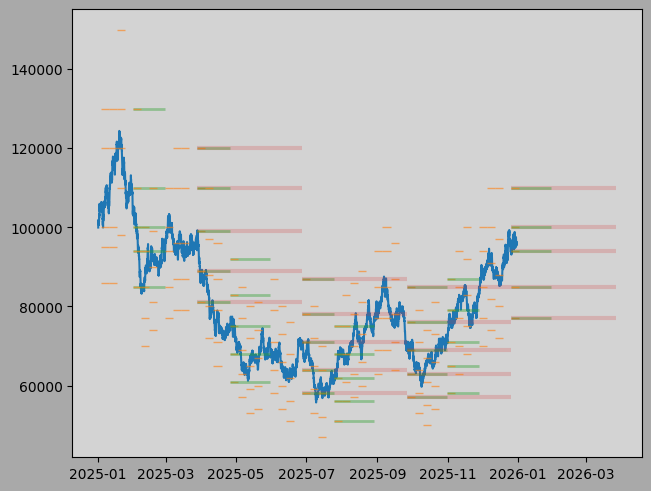

In [8]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(
    paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
    paths_mark.filter(pl.col("name").eq("btc")).collect()["price"],
)
for k, tl, te in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    dw = abs((te - tl) - timedelta(days=7))
    dm = abs((te - tl) - timedelta(days=30))
    dq = abs((te - tl) - timedelta(days=90))

    alphas = {dw: 0.6, dm: 0.4, dq: 0.2}
    colors = {dw: "tab:orange", dm: "tab:green", dq: "tab:red"}
    widths = {dw: 1, dm: 2, dq: 3}

    a = alphas[min(alphas.keys())]
    c = colors[min(colors.keys())]
    w = widths[min(widths.keys())]

    ax.hlines(k, tl, te, alpha=a, color=c, linewidth=w)

In [9]:
mdp = MarketDataProvider(path_rate, bars_spot, bars_option)
mdp

In [10]:
# TODO: implement MarketDataProvider._get_lf_priced(...)
mdp.get_target_option(
    "drbt",
    "btc",
    "usd",
    "c",
    target_time=datetime(2025, 6, 1, tzinfo=timezone.utc),
    target_delta=0.5,
    target_tenor=timedelta(days=30),
)

ColumnNotFoundError: unable to find column "exchange"; valid columns: ["time_start", "time_end", "exchange_option", "base_option", "quote_option", "strike", "listing", "expiry", "kind", "iv_bid", "iv_ask", "iv_mark", "base_spot", "px_mark_spot", "exchange_spot", "quote_spot", "px_bid_spot", "px_ask_spot", "rate", "px_bid_option", "px_ask_option", "px_mark_option", "delta", "gamma", "vega", "theta", "rho"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
 WITH_COLUMNS:
 [col("px_mark_spot").alias("px_bid_option"), col("px_mark_spot").alias("px_ask_option"), col("px_mark_spot").alias("px_mark_option"), col("px_mark_spot").alias("delta"), col("px_mark_spot").alias("gamma"), col("px_mark_spot").alias("vega"), col("px_mark_spot").alias("theta"), col("px_mark_spot").alias("rho")] 
  INNER JOIN:
  LEFT PLAN ON: [col("time_start"), col("time_end")]
    SELECT [col("time_start"), col("time_end"), col("exchange").alias("exchange_option"), col("base").alias("base_option"), c

## Normal CDF

In [11]:
import narwhals as nw
import numpy as np

from utils import stats

In [12]:
df = pl.DataFrame({"x": list(range(-100, 100))})
lf = df.lazy()

In [13]:
approx_pl: pl.Series = (
    nw.from_native(df)
    .lazy()
    .with_columns(nw.col("x").pipe(stats.norm_cdf).alias("cdf"))
    .collect()
    .to_native()["cdf"]
)
approx_np: np.ndarray = approx_pl.to_numpy().flatten()
approx_np

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      